In [1]:
# Iris flower classification project 

#import libraries 
import pandas as pd # for data handling 
import numpy as np # for numerical classification 
import matplotlib.pyplot as plt 
import seaborn as sns # for visualization

from sklearn.model_selection import train_test_split # to divide data inyo training and testing sets 
from sklearn.preprocessing import LabelEncoder #convert text into numbers 
from sklearn.ensemble import RandomForestClassifier #selecting ML algorithm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # to evaluate model performance



In [2]:
# load the dataset 

df = pd.read_csv(r"C:\Users\sohai\Downloads\archive (1).zip") #reading csv file 


In [3]:
#display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())


First 5 Rows of Dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
#display dataset information 
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [5]:
#display statistical summary 
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


In [6]:
#checking for missing values 
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


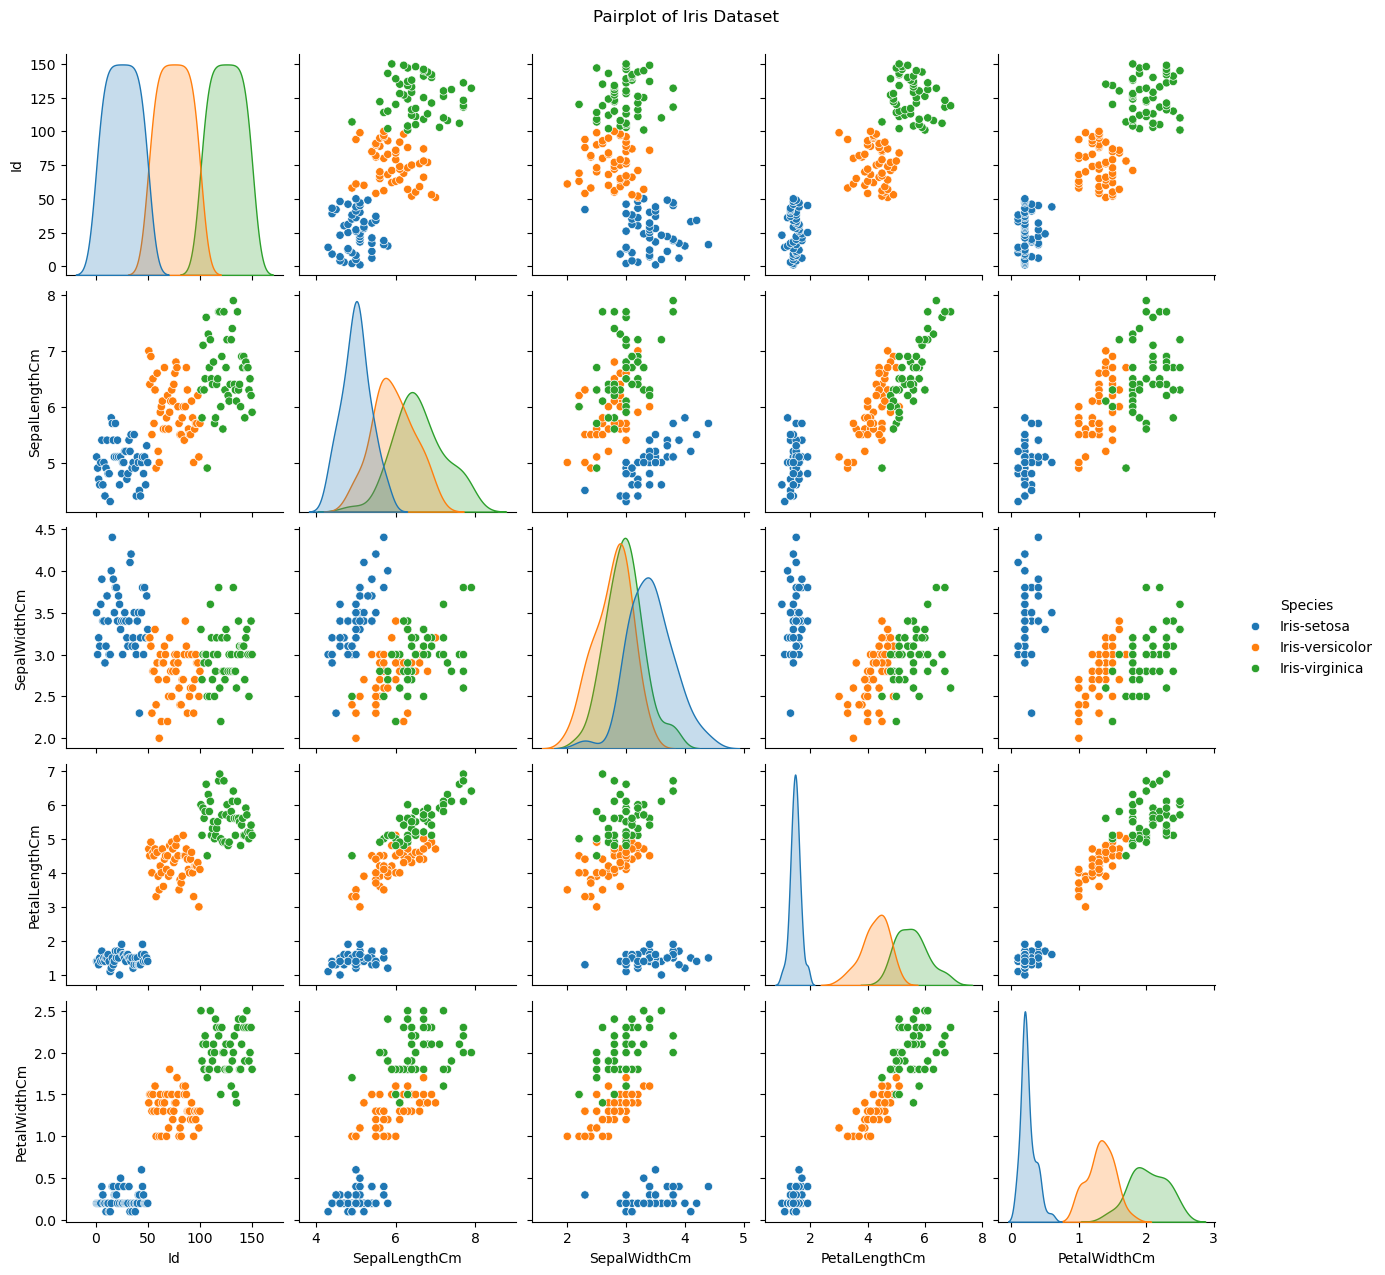

In [7]:
#visualize the data 
sns.pairplot(df, hue="Species")
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()
#pairplot is used to visualixe relationships b/w features 
#here different colors represent diff species 

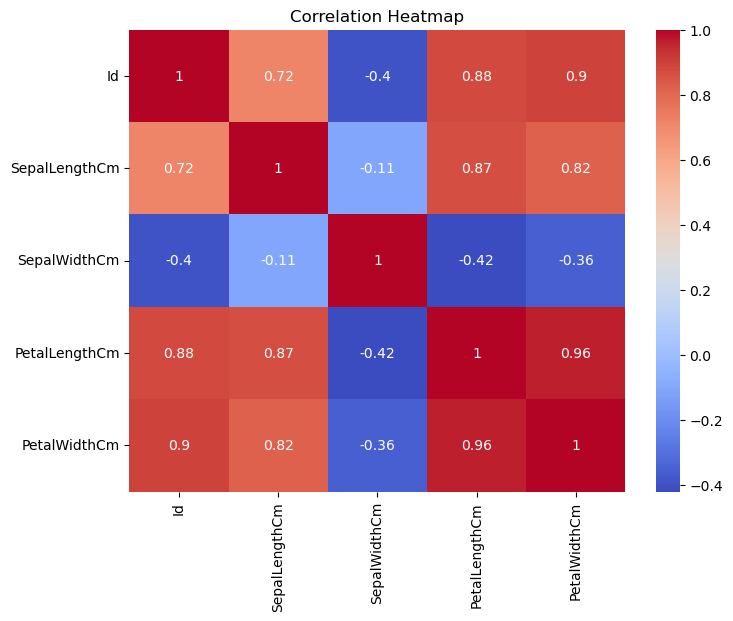

In [8]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()
#Correlation heatmap shows how strongly features are related

In [9]:
df = df.drop("Id", axis=1)
#here we remove the id because its just a serial number and does not help in prediction

In [10]:
#converting species name into numerical values 
encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

print("\nEncoded Dataset:")
print(df.head())


Encoded Dataset:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


In [11]:
#X is input feasture and Y is output feature
X = df.drop("Species", axis=1)
y = df["Species"]


In [12]:
#splitting the dataset 
# 80% for training and 20% for testing 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


In [13]:
#training the model 
model = RandomForestClassifier(random_state=42) #create Random forest classifier

#train the model using training dataa 
model.fit(X_train, y_train)
print("\nModel Training Completed Successfully")


Model Training Completed Successfully


In [14]:
#making prediction
y_pred = model.predict(X_test)
print("\nPredicted Values:")
print(y_pred)


Predicted Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [15]:
#model evaluation
#calculating accuracy 
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")


Model Accuracy:
100.00%


In [16]:
#classification report on performance 
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



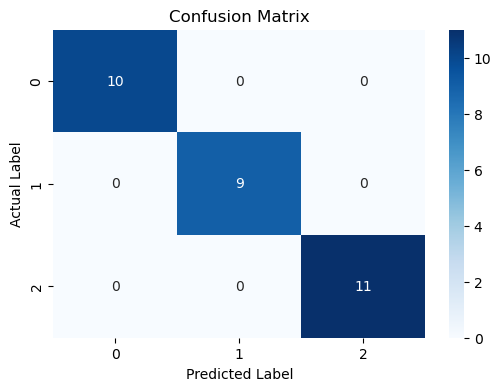

In [17]:
#cofusion matrix 
#shows correct predictions and incoreect predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap( cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [18]:
#sample testing with a new flower 
sample_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample_flower)

# convert numerical pprediction into species name 
species_name = encoder.inverse_transform(prediction)

print("\nPrediction for Sample Flower:")
print(species_name[0])



Prediction for Sample Flower:
Iris-setosa


C:\Users\sohai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [20]:
print(encoder.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
